# Logistic Regression for Classification

- Gabriel Wendell Celestino Rocha
---

## Required Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import h5py
from PIL import Image
import sklearn.linear_model

def opt_plot():
    # plt.style.use('dark_background')
    plt.grid(True, linestyle = ':', color = '0.50')
    plt.rcParams['text.usetex'] = True
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 15
    plt.minorticks_on()
    plt.tick_params(axis = 'both', which = 'minor', direction = "in",
                        top = True, right = True, length = 5, width = 1, labelsize = 15)
    plt.tick_params(axis = 'both', which = 'major', direction = "in",
                        top = True, right = True, length = 8, width = 1, labelsize = 15)

---

## 1. Decision boundary of a logistic regression model

### 1.1 Theory

A logistic regression binary classification model takes an input feature vector, ${\bf x}$, and returns a probability, $\hat{y}$, that ${\bf x}$ belongs to a particular class: $\hat{y}=\mathbb{P}\left(y=1|{\bf x}\right)$. The model is trained on a set of provided example feature vectors, ${\bf x}^{(i)}$, and their classifications $y^{(i)}=0$ or $1$, by finding the set of parameters that minimize the difference between $\hat{y}^{(i)}$ and $y^{(i)}$ in some sense.

These model parameters are the components of a vector, ${\bf w}$ and a constant, ${\bf b}$, which relate a given input feature vector to the predicted [logit](https://en.wikipedia.org/wiki/Logit) or log-odds, $z$, associated with ${\bf x}$ belonging to the class $y=1$ through:

$$
\tag{1.1}
z={\bf w}^{T}{\bf x}+b\text{ }.
$$

In this formulation:

$$\tag{1.2}
z=\ln{\left(\frac{\hat{y}}{1-y}\right)}\implies\hat{y}=\sigma\left(z\right)=\frac{1}{1+e^{-z}}\text{ }.
$$

Note that the relation between $z$ and the components of the feature vector, $x_{j}$, is linear. In particular, for a two-dimensional problem:

$$\tag{1.3}
z=w_{1}x_{1}+w_{w}x_{2}+b\text{ }.
$$

It is sometimes useful to be able to visualize the boundary line dividing the input space in which points are classified as belonging to the class of interest, $y=1$, from that space in which points do not. This could be achieved by calculating the prediction associated with $\hat{y}$ for a mesh of $\left(x_{1},x_{2}\right)$ points and plotting a contour plot (see e.g. this [scikit-learn example](https://scikit-learn.org/stable/auto_examples/linear_model/plot_logistic_multinomial.html)).

Alternatively, one can think of the decision boundary as the line $x_{2}=mx_{1}+c$, being defined by points for which $\hat{y}=0.5$ and hence $z=0$. For $x_{1}=0$ we have $x_{2}=c$ (the intercept) and:

$$\tag{1.4}
0=0+w_{2}x_{2}+b\implies c=-\frac{b}{w_{2}}\text{ }.
$$

For the gradient, $m$, consider two distinct points on the decision boundary, $\left(x_{1}^{a},x_{2}^{a}\right)$ and $\left(x_{1}^{b},x_{2}^{b}\right)$, so that:

$$\tag{1.5}
m=\frac{x_{2}^{b}-x_{2}^{a}}{x_{1}^{b}-x_{1}^{a}}\text{ }.
$$

Along the boudary line:

$$\tag{1.6}
0=w_{1}x_{1}^{b}+w_{2}x_{2}^{b}+b-\left(w_{1}x_{1}^{a}+w_{2}x_{2}^{b}+b\right)\implies -w_{2}\left(x_{2}^{b}-x_{2}^{a}\right)=w_{1}\left(x_{1}^{b}-x_{1}^{a}\right)\quad\therefore\quad \boxed{m=-\frac{w_{1}}{w_{2}}}\text{ }.
$$

### 1.2 Code

To see this in action, consider the data in [`linpts.txt`](https://github.com/GabrielWendell/Math-ML_Minicouse/blob/main/Notebooks/Examples/Data/linpts.txt), which maybe classified using [scikit-learn's `LogisticRegression` classifier](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html#sklearn.linear_model.LogisticRegression). The following script retrieves the decision boundary as above to generate the following visualization.

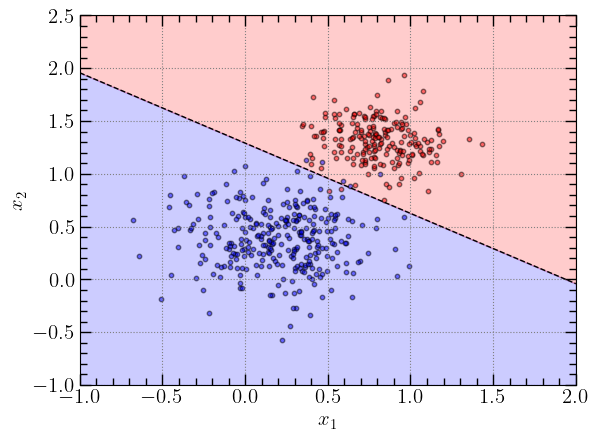

In [3]:
pts = np.loadtxt('Data/linpts.txt')
X = pts[:,:2]
Y = pts[:,2].astype('int')

# Fit the data to a logistic regression model.
clf = sklearn.linear_model.LogisticRegression()
clf.fit(X, Y)

# Retrieve the model parameters.
b = clf.intercept_[0]
w1, w2 = clf.coef_.T
# Calculate the intercept and gradient of the decision boundary.
c = -b/w2
m = -w1/w2

# Plot the data and the classification with the decision boundary.
xmin, xmax = -1, 2
ymin, ymax = -1, 2.5
xd = np.array([xmin, xmax])
yd = m*xd + c
plt.plot(xd, yd, 'k', lw = 1, ls = '--')
plt.fill_between(xd, yd, ymin, color = 'blue', alpha = 0.2)
plt.fill_between(xd, yd, ymax, color = 'red', alpha = 0.2)

plt.scatter(*X[Y == 0].T, s = 10, color = 'blue', edgecolors = 'black', alpha = 0.5)
plt.scatter(*X[Y == 1].T, s = 10, color = 'red', edgecolors = 'black', alpha = 0.5)
plt.xlim(xmin, xmax)
plt.ylim(ymin, ymax)
plt.ylabel(r'$x_2$')
plt.xlabel(r'$x_1$')

opt_plot()
plt.savefig("Plots/Logistic_Regression_Classification.png", dpi = 400)
plt.show()

---

## 2. Logistic Regression for Image Classification

### 2.1 Theory

Simple [logistic regression](https://en.wikipedia.org/wiki/Logistic_regression) is a statistical method that can be used for binary classification problems. In the context of image processing, this could mean identifying whether a given image belongs to a particular class $(y=1)$ or not $(y=0)$, e.g. "cat" or "not cat". A logistic regression algorithm takes as its input a feature vector ${\bf x}$ and outputs a probability, $\hat{y}=\mathbb{P}(y=1|{\bf x})$, that the feature vector represents an object belonging to the class. For images, the feature vector might be just the values of the red, green and blue (RGB) channels for each pixel in the image: a one-dimensional array of $n_{x}=n_{\text{height}}\times n_{\text{width}}\times3$ real numbers formed by flattening the three-dimensional array of pixel RGB values. A logistic regression model is so named because it calculates $\hat{y}=\sigma(z)$ where $\sigma(z)$ is the [logistic function](https://en.wikipedia.org/wiki/Logistic_function) and:

$$\tag{2.1}
\sigma(z)=\frac{1}{1+e^{-z}}\quad,\quad z={\bf w}^{T}{\bf x}+b\text{ },
$$

for a set of parameters, ${\bf w}$ and $b$. Also, ${\bf w}$ is a $n_{x}$-dimensional vector (one component for each component of the feature vector) and $b$ is a constant "bias".

Training a logistic regression algorithm involves obtaining the optimum values of ${\bf w}$ and $b$ such that $\hat{y}^{(i)}$ most closely predicts $y^{(i)}$ for a set of $m$ provided, pre-classified examples (i.e. $m$ images corresponding to feature vectors ${\bf x}^{(i)}$ for which the classification $y^{(i)}$ is known): this is a [*supervised learning*](https://en.wikipedia.org/wiki/Supervised_learning) technique. In practice, this usually means calculating the *loss function*:

$$\tag{2.2}
\mathcal{L}\left(\hat{y}^{(i)},y^{(i)}\right)=-\left[y^{(i)}\log{\hat{y}^{(i)}}+\left(1-y^{(i)}\right)\log{\left(1-\hat{y}^{(i)}\right)}\right]\text{ },
$$

for each training example, $i$, and minimizing the *cost function*:

$$\tag{2.3}
J\left({\bf w},b\right)=\frac{1}{m}\sum_{i=1}^{m}\mathcal{L}\left(\hat{y}^{(i)},y^{(i)}\right)\text{ },
$$

across all $m$ training examples. The loss function captures, in a way suitable for numerical minimization of $J$, the difference between the predicted and actual classification of each training example. It can be shown that:

$$\tag{2.4}
\frac{\partial\mathcal{L}}{\partial w_{j}}=\left(\hat{y}^{(i)}-y^{(i)}\right)x_{j}^{(i)}\quad\text{and}\quad\frac{\partial\mathcal{L}}{\partial b}=\hat{y}^{(i)}-y^{(i)}\text{ },
$$

where $i=1,2,\ldots,n_{x}$ labels the components of the feature vector.

In numerically minimizing $J\left({\bf w},b\right)$ one starts with an initial guess for $w_{j}$ and $b$ and uses these expressions to determine how to change them iteratively so that $J$ keeps decreasing. That is, on each iteration the values of the parameters are changed according to descent along the steepest gradient:

$$\tag{2.5}
w_{j}\rightarrow w_{j}-\alpha\frac{\partial J}{\partial w_{j}}=w_{j}-\frac{\alpha}{m}\sum_{i=1}^{m}\frac{\partial\mathcal{L}}{\partial w_{j}}\text{ },
$$

and similarly for $b$, where $\alpha$ is some [*learning rate*](https://en.wikipedia.org/wiki/Learning_rate) that determines how large each step taken in the direction of greatest decrease in $J$ is. Choosing a suitable value for $\alpha$ is a subtle art (too small and the training is slow, too large and the steps taken in gradient descent are too large and the training may not converge reliably on the minimum in $J$), but for small, simple problems can be determined by trial-and-error.



### 2.2 The Code

The following script trains this simple model to discriminate between pictures of [Afghan Hounds](https://en.wikipedia.org/wiki/Afghan_Hound) and [Bedlington Terriers](https://en.wikipedia.org/wiki/Bedlington_Terrier) (a fairly sympathetic task, given the dogs have quite different colours). The [training](https://github.com/GabrielWendell/Math-ML_Minicouse/blob/main/Notebooks/Examples/Data/dogs_train.h5) and [test](https://github.com/GabrielWendell/Math-ML_Minicouse/blob/main/Notebooks/Examples/Data/dogs_test.h5) data are provided as HDF5 files and have been obtained by cropping and resizing images from the [Stanford Dogs Dataset](http://vision.stanford.edu/aditya86/ImageNetDogs/main.html). Here is one image from each class:

In [4]:
# Training rate
alpha = 0.002

def sigmoid(z):
    """Return the logistic function sigma(z) = 1/(1+exp(-z))."""
    return 1 / (1+np.exp(-z))

def cost(Y, Yhat):
    """Return the cost function for predictions Yhat of classifications Y."""
    return (- Y @ np.log(Yhat.T) - (1 - Y) @ np.log(1 - Yhat.T)) / m

def accuracy(Y, Yhat):
    """Return measure of the accuracy with which Yhat predicts Y."""
    return 1 - np.mean(np.abs(Y - Yhat.round()))

def model(X, w, b):
    """Apply the logistic model parameterized by w, b to features X."""
    z = w.T @ X + b
    Yhat = sigmoid(z)
    return z, Yhat

def train(X, Y, max_it = 1000):
    """Train the logistic regression algorithm on the data X classified as Y."""

    # Parameter vector, w, and constant term (bias), b.
    # For random initialization, use the following:
    #w, b = np.random.random((nx,1)) * 0.01, 0.01
    # To initialize with zeros, use this line instead:
    w, b = np.zeros((nx,1)), 0

    def propagate(w, b):
        """Propagate the training by advancing w, b to reduce the cost, J."""
        z, Yhat = model(X, w, b)
        w -= alpha / m * (X @ (Yhat - Y).T)
        b -= alpha / m * np.sum(Yhat - Y)
        J = np.squeeze(cost(Y, Yhat))
        if not it % 100:
            # Provide an update on the progress we have made so far.
            print('Iteration {} : J = {}'.format(it, J))
            print('train accuracy = {:g}%'.format(accuracy(Y, Yhat) * 100))
            print(' ')
        return w, b

    # Train the model by iteratively improving w, b.
    for it in range(max_it):
        w, b = propagate(w, b)
    return w, b

- The output indicates a reasonable model which discriminates between the two dog breeds $82\%$ of the time on the test data:

In [5]:
# Our training data, in an HDF5 file.
ds_train = h5py.File('Data/dogs_train.h5', 'r')

# Normalise the pixel data (RGB channels) to be in the range 0-1.
ds_x = np.array(ds_train["dogs_train_x"]).T / 255
ds_y = np.array(ds_train["dogs_train_y"])

# Number of training examples.
m = len(ds_y)
# Dimension of the feature vector for each example.
nx = ds_x.size // m
# Packed feature vector and associated classification.
X, Y = ds_x.reshape((nx, m)), ds_y.reshape((1, m))

# Train the model
w, b = train(X, Y)


# Now the test data
ds_test = h5py.File('Data/dogs_test.h5', 'r')
ds_x = np.array(ds_test["dogs_test_x"]).T / 255
ds_y = np.array(ds_test["dogs_test_y"])
# Number of test examples.
m = len(ds_y)
# Dimension of the feature vector for each example.
nx = ds_x.size // m
# Packed feature vector and associated classification.
X, Y = ds_x.reshape((nx, m)), ds_y.reshape((1,m))

z, Yhat = model(X, w, b)
print("")
print('test accuracy = {}%'.format(accuracy(Y, Yhat) * 100))

Iteration 0 : J = 0.6931471805599454
train accuracy = 49.3976%
 
Iteration 100 : J = 0.4064668073673639
train accuracy = 83.9357%
 
Iteration 200 : J = 0.30963910029260355
train accuracy = 92.7711%
 
Iteration 300 : J = 0.27044432864585144
train accuracy = 93.1727%
 
Iteration 400 : J = 0.2403748716897043
train accuracy = 94.7791%
 
Iteration 500 : J = 0.21618082409768014
train accuracy = 96.3855%
 
Iteration 600 : J = 0.19619621946830756
train accuracy = 96.7871%
 
Iteration 700 : J = 0.17939225598255612
train accuracy = 97.1888%
 
Iteration 800 : J = 0.16506777147246005
train accuracy = 97.5904%
 
Iteration 900 : J = 0.15271922035318536
train accuracy = 97.5904%
 

test accuracy = 82.35294117647058%


- The further test images used are an [Afgha](https://github.com/GabrielWendell/Math-ML_Minicouse/blob/main/Notebooks/Examples/Data/afghan.png) (correctly classified), a [Bedlington Terrier](https://github.com/GabrielWendell/Math-ML_Minicouse/blob/main/Notebooks/Examples/Data/bedlington.png) (correctly classified), and a [lamb](https://github.com/GabrielWendell/Math-ML_Minicouse/blob/main/Notebooks/Examples/Data/lamb.png) that gets classified as a Bedlington Terrier.

In [6]:
def categorize_image(filename):
    """Categorize the image provided in filename.

    Return 1 if the image is categorized in the y = 1 class and otherwise 0.

    """

    im = Image.open(filename)
    ds_x = np.asarray(im, dtype = 'uint8')[:, :, :3].T / 255
    ds_y = np.array([1])
    # Number of test examples.
    m = len(ds_y)
    # Dimension of the feature vector for each example.
    nx = ds_x.size // m
    # Packed feature vector and associated classification.
    X, Y = ds_x.reshape((nx, m)), ds_y.reshape((1,m))
    z, Yhat = model(X, w, b)
    return np.squeeze(Yhat) > 0.5

def report_category(filename, predictedY):
    s = 'a Bedlington Terrier' if predictedY else 'an Afghan Hound'
    print(filename, 'is ' + s)

filename = 'Data/afghan.png'
report_category(filename, categorize_image(filename))

filename = 'Data/bedlington.png'
report_category(filename, categorize_image(filename))

filename = 'Data/lamb.png'
report_category(filename, categorize_image(filename))

Data/afghan.png is an Afghan Hound
Data/bedlington.png is a Bedlington Terrier
Data/lamb.png is a Bedlington Terrier


---